# Feature Importance Analysis with Integrated Gradients

In [1]:
from pydoc import locate
from typing import Any

from captum.attr import IntegratedGradients
import lightning as L
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
import pandas as pd
from rich.progress import track
import torch
from torch import Tensor, nn
import wandb
import xarray as xr

from deeprec.data import DeepRecDataModule
from deeprec.utils import ROOT_DIR, wandb_checkpoint_download

In [2]:
set_matplotlib_formats("retina")
plt.style.use(ROOT_DIR / "config/style_paper.mplstyle")

FIGURE_DIR = ROOT_DIR / "figures/si"

In [3]:
COMPUTE = False

In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"{device = }")

device = device(type='mps')


## Load model weights

In [5]:
run_ids = [
    "6pz8pwa4",
    "fwluwkso",
    "tihk28jt",
    "vd3y6ay8",
    "t4eu3ggb",
]
wandb_project = "deeprec-paper_ensembles"

In [6]:
def set_bn_eval(module: nn.Module) -> None:
    """Recursively set all BatchNorm layers to eval mode."""
    if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
        module.eval()
    for child in module.children():
        set_bn_eval(child)

In [7]:
def download_run(run_id: str, project: str) -> tuple[L.LightningModule, dict[str, Any]]:
    api = wandb.Api()
    # Download checkpoint
    ckpt_file = wandb_checkpoint_download(project=project, run_id=run_id, alias="best")
    # Download model config
    run = api.run(f"{project}/{run_id}")
    config = run.config
    # Model creation
    model_class = locate(config["model"]["class_path"])
    if issubclass(model_class, L.LightningModule):
        model = model_class.load_from_checkpoint(ckpt_file, **config["model"])
    else:
        raise TypeError(f"Provided class_path '{model_class}' is not a LightningModule.")
    model.to(device)
    # Keep model in training mode
    model.train()
    # But freeze BatchNorm layers
    set_bn_eval(model)
    return model, config

In [8]:
class ModelWrapper(L.LightningModule):
    """Wraps the model to accept tuples instead of a dictionary.

    Only returns TWSA (mu), not the uncertainty (b)."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, xt: Tensor, xm: Tensor, xv: Tensor):
        # Manually set requires_grad to True as we do not use PyTorch Lightning
        xt = xt.requires_grad_()
        xm = xm.requires_grad_()
        xv = xv.requires_grad_()
        # forward pass
        out = self.model(tensor_inputs=xt, matrix_inputs=xm, vector_inputs=xv)

        # Only return the mean (first output)
        mu_idx = 0
        return out[:, mu_idx]

In [9]:
# Get config and models of all runs
configs = []
models = []
for run_id in run_ids:
    model, config = download_run(run_id, wandb_project)
    models.append(ModelWrapper(model))
    configs.append(config)

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


## Calculate Integrated Gradients with Captum

In [10]:
import numpy as np
from torch.utils.data import DataLoader, Dataset, Subset

from deeprec.data.dataset import DeepRecDataset

In [11]:
# Data creation (all configs are identical)
dm = DeepRecDataModule(**configs[0]["data"])
# Use inputs during train time (range for baseline calc)
times_train = dm._time_train
start, end = times_train[0], times_train[-1]
inputs = dm._inputs.sel(time=slice(start, end))

In [12]:
# Get tensors for the unchanged inputs
# We use the predict stage as it leaves inputs in original order
dm._inputs = inputs
dm.setup("predict")
data_inputs = DeepRecDataset(
    dm._predict_tensors,
    space_window=dm._space_window,
    time_window=dm._time_window,
)

DataModule: Preparing predict tensors...


In [13]:
# Use a zero baseline
inputs_baseline = xr.zeros_like(inputs)
# Create a baseline dataloader
dm._inputs = inputs_baseline
dm.setup("predict")
data_baseline = DeepRecDataset(
    dm._predict_tensors,
    space_window=dm._space_window,
    time_window=dm._time_window,
)

DataModule: Preparing predict tensors...


In [14]:
def create_sampled_dataloaders(
    ds_inputs: Dataset,
    ds_baselines: Dataset,
    sample_size: int,
    batch_size: int,
    seed: int = 42,
    **dataloader_kwargs,
) -> tuple[DataLoader, DataLoader]:
    """Creates input and baseline dataloaders with randomly sampled subset of data.

    More efficient than iterating through all batches.
    """
    rng = np.random.default_rng(seed)

    # Randomly select sample indices from dataset
    if not len(ds_inputs) == len(ds_baselines):
        raise ValueError
    total_dataset_size = len(ds_inputs)
    selected_indices = rng.choice(
        total_dataset_size,
        size=min(sample_size, total_dataset_size),
        replace=False,
    )
    # Create subset dataloaders
    dl_inputs = DataLoader(
        Subset(ds_inputs, selected_indices),
        batch_size=batch_size,
        shuffle=False,
        **dataloader_kwargs,
    )
    dl_baselines = DataLoader(
        Subset(ds_baselines, selected_indices),
        batch_size=batch_size,
        shuffle=False,
        **dataloader_kwargs,
    )

    return dl_inputs, dl_baselines

In [15]:
def dict_to_tuple(dict_: dict[str, Tensor], device: torch.device) -> tuple[Tensor, Tensor, Tensor]:
    input_order = ("tensor_inputs", "matrix_inputs", "vector_inputs")
    return tuple(dict_[inp].to(device) for inp in input_order)

In [16]:
def get_attributions(
    model: ModelWrapper, dl_inputs: DataLoader, dl_baselines: DataLoader
) -> dict[str, np.ndarray]:
    ig = IntegratedGradients(model)
    att_t_sum_list = []
    att_m_sum_list = []
    att_v_sum_list = []

    for b_input, b_baseline in zip(dl_inputs, dl_baselines):
        b_input = dict_to_tuple(b_input["inputs"], device)
        b_baseline = dict_to_tuple(b_baseline["inputs"], device)

        # Calculate attributions
        attributions = ig.attribute(
            b_input,
            baselines=b_baseline,
            method="riemann_trapezoid",
            n_steps=50,
            internal_batch_size=256,
        )

        att_t, att_m, att_v = attributions
        # Sum over time, lat, lon
        att_t_sum = att_t.sum(dim=[-3, -2, -1]).cpu().numpy()
        # Sum over lat, lon
        att_m_sum = att_m.sum(dim=[-2, -1]).cpu().numpy()
        # Sum over time
        att_v_sum = att_v.sum(dim=-1).cpu().numpy()

        att_t_sum_list.append(att_t_sum)
        att_m_sum_list.append(att_m_sum)
        att_v_sum_list.append(att_v_sum)

    return {
        "tensor_inputs": np.concat(att_t_sum_list),
        "matrix_inputs": np.concat(att_m_sum_list),
        "vector_inputs": np.concat(att_v_sum_list),
    }

In [17]:
if COMPUTE:
    # Samples per model
    SAMPLE_SIZE = 5_000
    BATCH_SIZE = 256

    # Calculate attributions
    atts_t = []
    atts_m = []
    atts_v = []

    for i, model in enumerate(track(models)):
        inp, bl = create_sampled_dataloaders(
            data_inputs,
            data_baseline,
            sample_size=SAMPLE_SIZE,
            batch_size=BATCH_SIZE,
            seed=i,
        )
        att = get_attributions(model, inp, bl)
        atts_t.append(att["tensor_inputs"])
        atts_m.append(att["matrix_inputs"])
        atts_v.append(att["vector_inputs"])

    att_t = np.concat(atts_t)
    att_m = np.concat(atts_m)
    att_v = np.concat(atts_v)


In [18]:
save_dir = ROOT_DIR / "models/attributions"
save_dir.mkdir(parents=True, exist_ok=True)

if COMPUTE:
    # Save
    np.save(save_dir / "att_t.npy", att_t)
    np.save(save_dir / "att_m.npy", att_m)
    np.save(save_dir / "att_v.npy", att_v)

att_t = np.load(save_dir / "att_t.npy")
att_m = np.load(save_dir / "att_m.npy")
att_v = np.load(save_dir / "att_v.npy")

## Box plots

In [19]:
rename = {
    "era5_d2m": "Dewpoint temp 2m",
    "era5_t2m": "Temperature 2m",
    "era5_e": "Evaporation",
    "era5_lai_hv": "LAI, high",
    "era5_lai_lv": "LAI, low",
    "era5_pev": "Potential evaporation",
    "era5_ro": "Runoff",
    "era5_ssro": "Sub-surface runoff",
    "era5_sro": "Surface runoff",
    "era5_sp": "Surface pressure",
    "era5_tp": "Total precipitation",
    "era5_swvl1": "Soil water, lyr. 1",
    "era5_swvl2": "Soil water, lyr. 2",
    "era5_swvl3": "Soil water, lyr. 3",
    "era5_swvl4": "Soil water, lyr. 4",
    "cropland_irrigated": "Cropland irrigated",
    "cropland_rainfed": "Cropland rainfed",
    "pastures": "Pastures",
    "urbanareas": "Urban areas",
    "lakes": "Lakes",
    "cell_area": "Cell area",
    "nvec_x": "n-vector, X",
    "nvec_y": "n-vector, Y",
    "nvec_z": "n-vector, Z",
    "year_cos": "Annual, cosine",
    "year_sin": "Annual, sine",
    "year2_cos": "Semiannual, cosine",
    "year2_sin": "Semiannual, sine",
    "oni": "Oceanic Niño Index (ONI)",
}


In [20]:
def plot_attributions_box(
    data: np.ndarray, labels: list[str], *, abs: bool = False, ax: plt.Axes
) -> None:
    if abs:
        data = np.abs(data)
    medians = np.median(data, axis=0)
    order = np.argsort(medians)
    data = data[:, order]
    labels = [labels[i] for i in order]
    labels = [rename[label] for label in labels]

    ax.axvline(0, color="lightgray", linewidth=1.2, zorder=-100)
    bplot = ax.boxplot(
        data,
        showfliers=False,
        orientation="horizontal",
        tick_labels=labels,
        patch_artist=True,
    )
    for patch in bplot["boxes"]:
        patch.set(facecolor="lightgray", linewidth=0.8)
    for patch in bplot["caps"]:
        patch.set(linewidth=0.8)
    for patch in bplot["whiskers"]:
        patch.set(linewidth=0.8)

    # Show mean as a dot
    means = np.mean(data, axis=0)
    ypos = np.arange(1, data.shape[1] + 1)
    ax.scatter(means, ypos, color="black", zorder=4, s=1)
    for line in bplot["medians"]:
        line.set(color="black", linewidth=0.8)
    ax.set(xlabel="Integrated gradient", ylabel=None)
    ax.axes.grid()

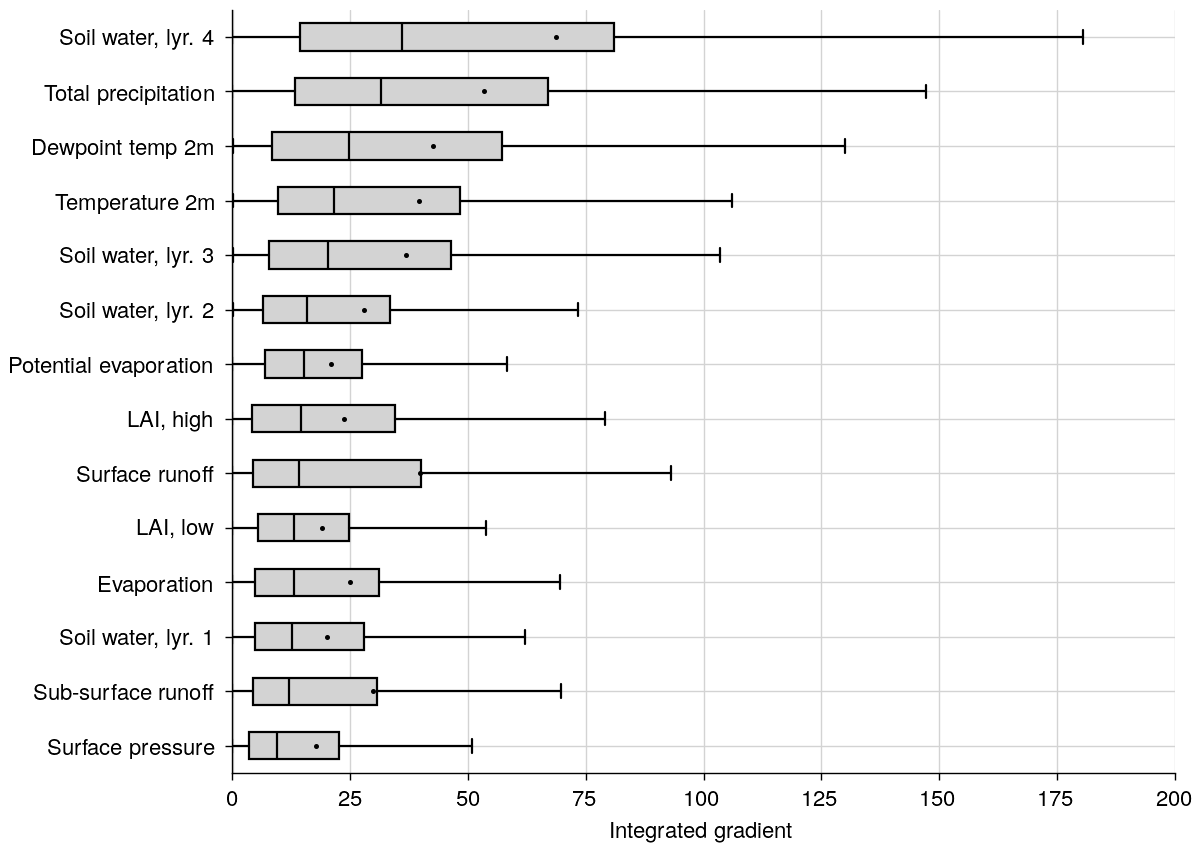

In [21]:
data = att_t
labels = dm._tensor_input_vars
height = (len(labels) + 3) / 4
fig, ax = plt.subplots(figsize=(6, height))
plot_attributions_box(data, labels, abs=True, ax=ax)
# ax.set(xlim=(-0.8, 0.8), title="Attributions of spatiotemporal inputs");
ax.set(xlim=(0, 200));

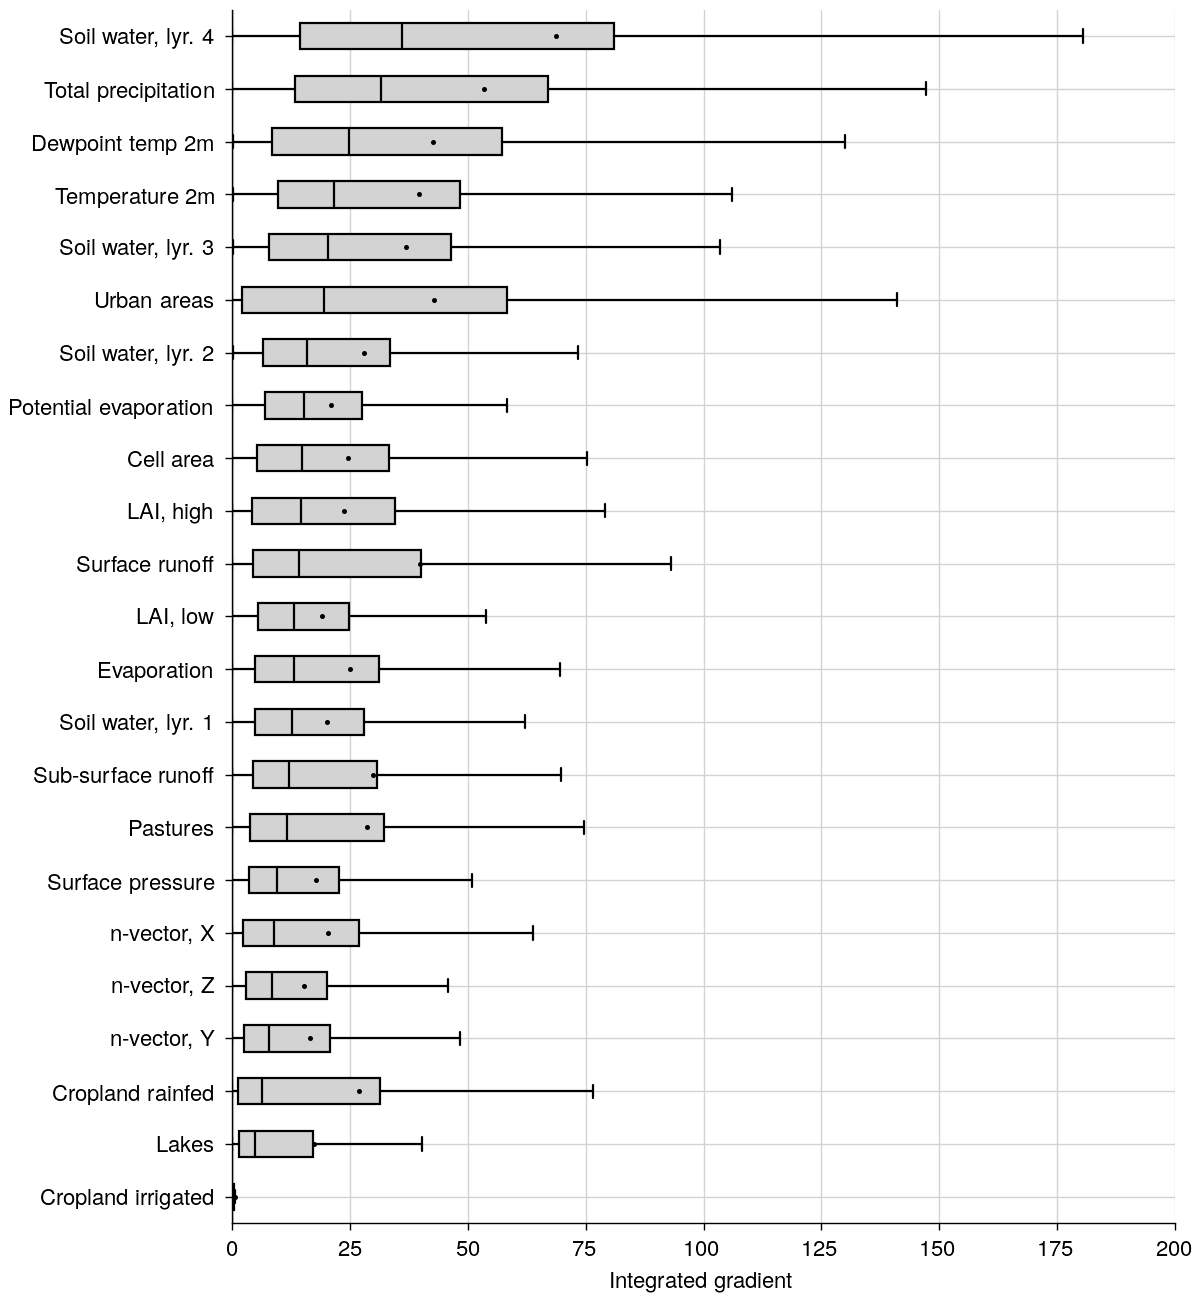

In [22]:
data = np.concat([att_t, att_m], axis=1)
labels = dm._tensor_input_vars + dm._matrix_input_vars

height = (len(labels) + 3) / 4
fig, ax = plt.subplots(figsize=(6, height))
plot_attributions_box(data, labels, abs=True, ax=ax)
ax.set(xlim=(0, 200))
fig.savefig(FIGURE_DIR / "attributions_box_spatial.pdf", backend="pgf")

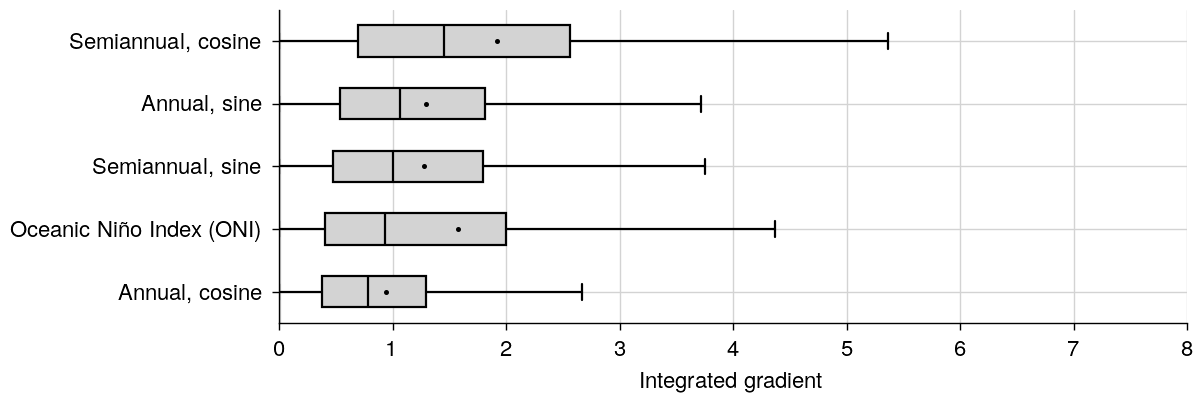

In [23]:
data = att_v
labels = dm._vector_input_vars

height = (len(labels) + 3) / 4
fig, ax = plt.subplots(figsize=(6, height))
plot_attributions_box(data, labels, abs=True, ax=ax)
ax.set(xlim=(0, 8))
fig.savefig(FIGURE_DIR / "attributions_box_temporal.pdf", backend="pgf")

## Bar charts

In [24]:
def plot_attributions_bar(data: np.ndarray, labels: list[str], ax: plt.Axes) -> None:
    Y_END_BUFFER = 0.75

    # Calculate statistics on absolute values
    abs_data = np.abs(data)
    abs_medians = np.median(abs_data, axis=0)
    abs_q25 = np.percentile(abs_data, 25, axis=0)
    abs_q75 = np.percentile(abs_data, 75, axis=0)

    # Sort by median
    order = np.argsort(abs_medians)
    medians_sorted = abs_medians[order]
    q25_sorted = abs_q25[order]
    q75_sorted = abs_q75[order]
    labels_sorted = [labels[i] for i in order]
    labels_sorted = [rename[label] for label in labels_sorted]

    # Create bars
    ax.barh(labels_sorted, medians_sorted, height=0.7)

    # Add error bars showing IQR (Q1 to Q3)
    lower_errors = medians_sorted - q25_sorted
    upper_errors = q75_sorted - medians_sorted

    ax.errorbar(
        medians_sorted,
        range(len(labels_sorted)),
        xerr=[lower_errors, upper_errors],
        fmt="none",
        ecolor="black",
        capsize=3,
        capthick=0.8,
        linewidth=0.8,
        zorder=3,
    )

    ax.set(
        xlabel="median(|Integrated gradient|)",
        ylim=(-Y_END_BUFFER, len(labels_sorted) - 1 + Y_END_BUFFER),
    )
    ax.tick_params(axis="y", length=0)
    ax.xaxis.grid()

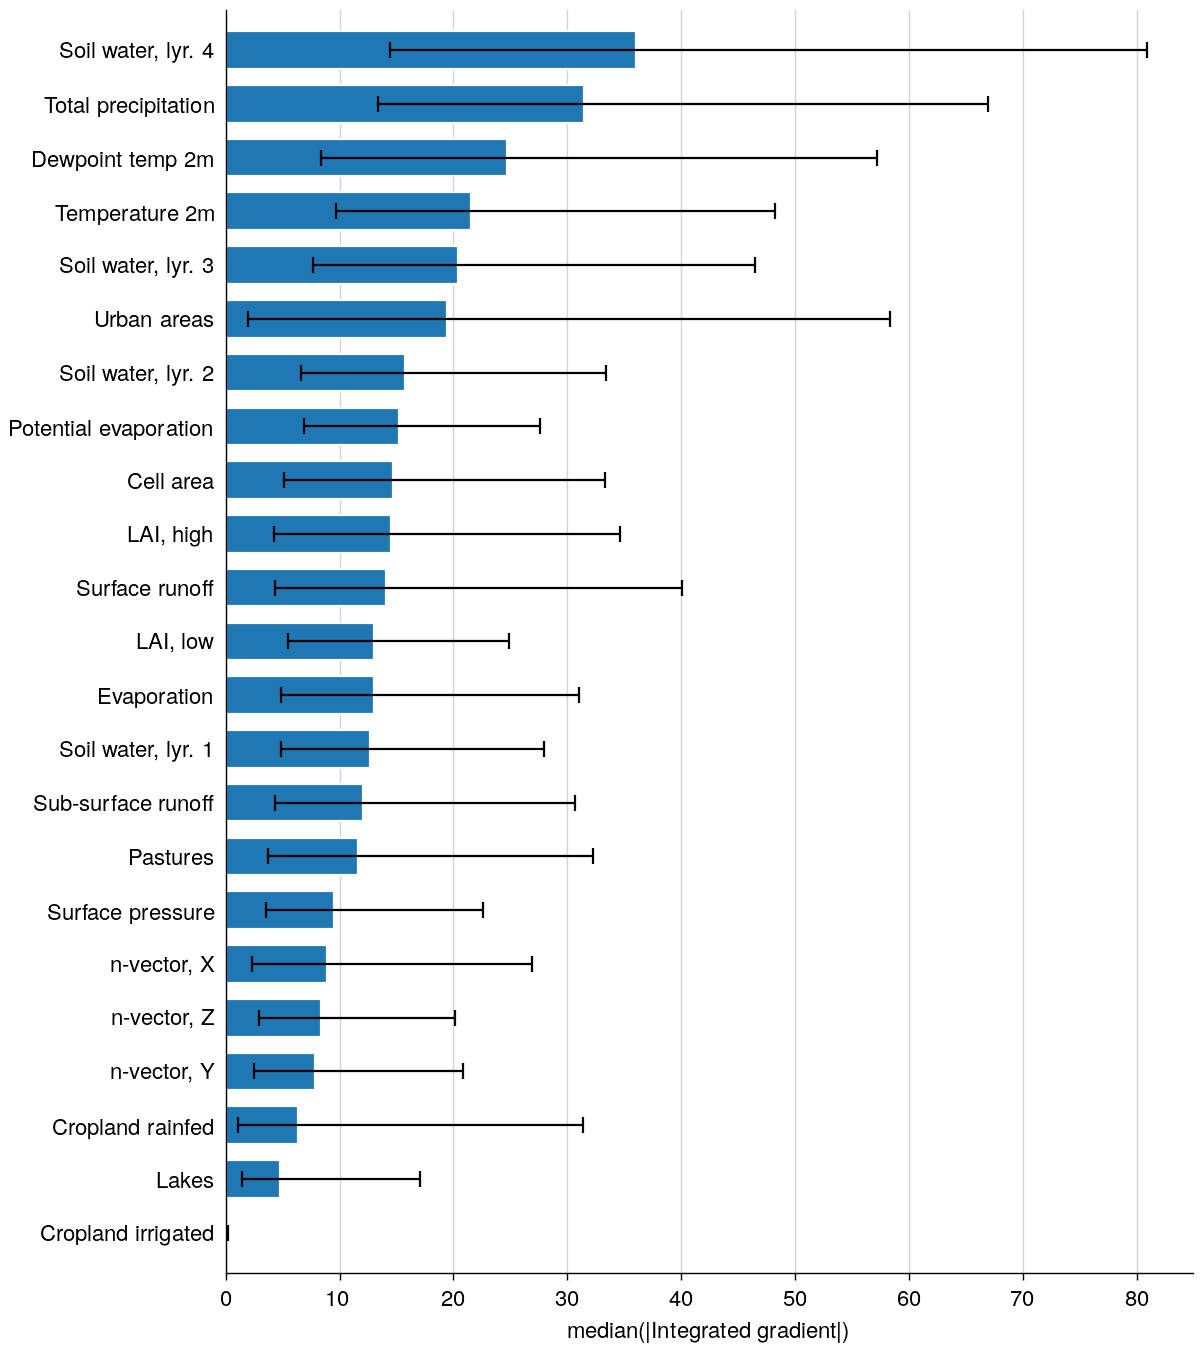

In [25]:
data = np.concat([att_t, att_m], axis=1)
labels = dm._tensor_input_vars + dm._matrix_input_vars
height = len(labels) / 4 + 1
fig, ax = plt.subplots(figsize=(6, height))
plot_attributions_bar(data, labels, ax)
# ax.set(xlim=(0, 80))
fig.savefig(FIGURE_DIR / "attributions_bar_spatial.pdf", backend="pgf")

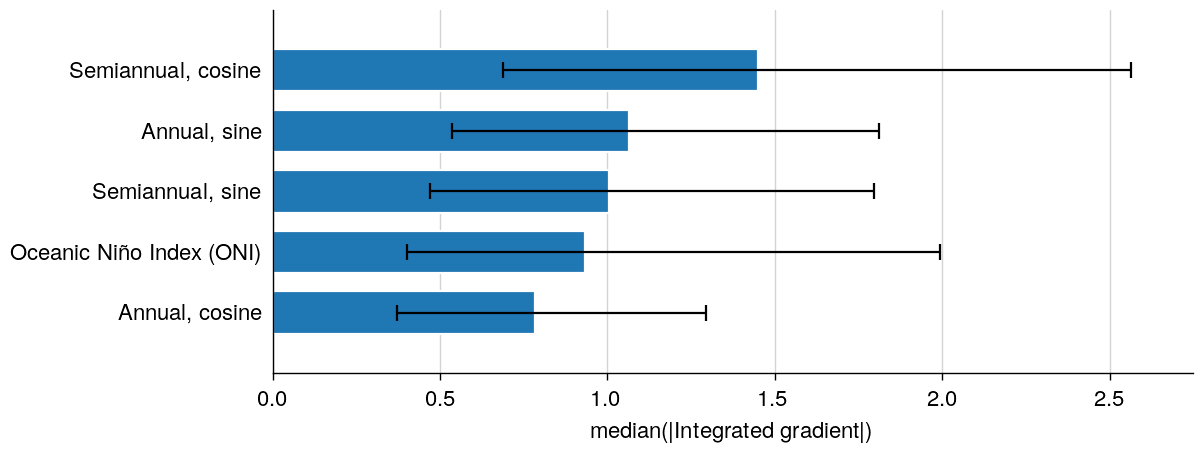

In [26]:
data = att_v
labels = dm._vector_input_vars
height = len(labels) / 4 + 1
fig, ax = plt.subplots(figsize=(6, height))
plot_attributions_bar(data, labels, ax)
ax.set(xlim=(0, 2.75), ylim=(-1, len(labels)))
fig.savefig(FIGURE_DIR / "attributions_bar_temporal.pdf", backend="pgf")

## Tables

In [27]:
# Get dataframe with attribution mean and std
def get_attribution_df(attribution_batch: np.ndarray, feature_names: list[str]) -> pd.DataFrame:
    abs = np.abs(attribution_batch)
    medians = np.median(abs, 0)
    means = np.mean(abs, 0)
    stds = abs.std(0, ddof=1)
    q1 = np.percentile(abs, 25, axis=0)
    q3 = np.percentile(abs, 75, axis=0)

    return pd.DataFrame(
        data={
            "median": medians,
            "mean": means,
            "ratio": means / medians,
            "std": stds,
            "iqr": q3 - q1,
            "q1": q1,
            "q3": q3,
        },
        index=feature_names,
    ).sort_values("median", ascending=False)

In [28]:
data = np.concat([att_t, att_m], axis=1)
labels = dm._tensor_input_vars + dm._matrix_input_vars

series_att_t_abs = get_attribution_df(data, labels)
series_att_v_abs = get_attribution_df(att_v, dm._vector_input_vars)

print("Tensor inputs:")
display(series_att_t_abs)
print("\nVector inputs:")
display(series_att_v_abs)

Tensor inputs:


,median,mean,ratio,std,iqr,q1,q3
era5_swvl4,36.058884,68.602577,1.902515,102.325554,66.462151,1.445334e+01,80.915489
era5_tp,31.456890,53.404762,1.697713,68.379646,53.592403,1.337753e+01,66.969933
era5_d2m,24.718044,42.594940,1.723233,50.453205,48.766289,8.389709e+00,57.155998
era5_t2m,21.565601,39.547020,1.833801,51.291328,38.568420,9.663263e+00,48.231682
era5_swvl3,20.366343,36.860977,1.809897,48.984230,38.741341,7.693239e+00,46.434578
urbanareas,19.453455,42.701668,2.195069,61.382885,56.372780,1.942033e+00,58.314812
era5_swvl2,15.738283,27.913670,1.773616,41.869530,26.786655,6.570426e+00,33.357082
era5_pev,15.173593,20.945026,1.380360,21.504953,20.658550,6.915395e+00,27.573946
cell_area,14.729656,24.489500,1.662598,29.146675,28.176399,5.128510e+00,33.304909
era5_lai_hv,14.484629,23.755949,1.640080,28.111444,30.340347,4.253712e+00,34.594059



Vector inputs:


,median,mean,ratio,std,iqr,q1,q3
year2_cos,1.451120,1.922276,1.324684,1.856165,1.873162,0.689449,2.562611
year_sin,1.064458,1.294906,1.216494,1.030747,1.277185,0.535126,1.812311
year2_sin,1.005286,1.271716,1.265029,1.111768,1.324227,0.470586,1.794814
oni,0.932551,1.571227,1.684870,1.987751,1.593742,0.400350,1.994091
year_cos,0.784664,0.942829,1.201571,0.757071,0.920992,0.372950,1.293943
